# Прогноз EPA combined fuel consumption

**SE-2421 — Tsybus Nikita и Bakytzhan Kassymgali.**

Как точно можно предсказать EPA combined расход бензиновых автомобилей и SUV рынка США
по объему двигателя, цилиндрам, трансмиссии, приводу, классу, производителю и модельному году?
Одна строка — одна принятая конфигурация с EPA vehicle ID. Объект прогноза —
стандартизованная EPA оценка, а не фактический расход конкретного водителя.
Результат помогает сравнивать спецификации автомобилей в рамках покрытия нашей выборки.

Notebook проверяет достаточность числа строк и читает сохраненный grouped benchmark. Число строк само по себе не доказывает полноту API-каталога или отсутствие смещения выборки. 

Источник: https://www.fueleconomy.gov/feg/ws/index.shtml. Собственный collector получает
индивидуальные записи, сохраняет raw bytes, manifest, даты и checksums. Notebook работает
offline: читает завершенный run либо заново обучает четыре заранее заданные модели
во временной папке. Критерии курса разобраны в `docs/REQUIREMENTS.md`.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from fuel_consumption.utils import project_root, load_config, sha256_file
from fuel_consumption.split import read_dataset, load_frozen_split
from fuel_consumption.train import run_midterm

ROOT = project_root()
DATASET = ROOT / 'data/processed/vehicles.parquet'
SPLIT_DIR = ROOT / 'data/splits'
AUDIT_DIR = ROOT / 'reports/audit/benchmark_2015_2025_20261009'
CONFIG = ROOT / 'configs/project.json'
EXISTING_RUN = 'models/midterm_v1'
ALLOW_SMALL = False
config = load_config(CONFIG)
df = read_dataset(DATASET)
if len(df) < config['scope']['minimum_distinct_rows'] and not ALLOW_SMALL:
    raise ValueError('Недостаточно строк для Midterm; --allow-small только для технической проверки')
manifest, split_info = load_frozen_split(DATASET, CONFIG, SPLIT_DIR)
merged = df.merge(manifest[['vehicle_id', 'split', 'cv_fold']], on='vehicle_id', validate='one_to_one')
train = merged.loc[merged['split'].eq('train')].copy()
feature_cols = config['features']['numeric'] + config['features']['categorical']
target = config['target']['name']
small_threshold = config['evaluation']['small_subgroup_threshold']
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False})
display(Markdown(f'**Покрытие:** {len(df):,} конфигураций, {df.manufacturer.nunique()} производителей, '
                 f'{df.vehicle_class.nunique()} классов, годы {int(df.model_year.min())}–{int(df.model_year.max())}. '
                 f'Train: {len(train):,}; test: {len(df)-len(train):,}.'))
display(df.groupby(['model_year', 'manufacturer']).size().rename('rows').to_frame())

**Покрытие:** 3,247 конфигураций, 49 производителей, 12 классов, годы 2015–2025. Train: 2,628; test: 619.

rows
model_year manufacturer      
2015       Acura           10
           Alfa Romeo       1
           Aston Martin    10
           Audi             8
           BMW             10
...                       ...
2025       Porsche          8
           Rolls-Royce      7
           Subaru           8
           Toyota           5
           Volkswagen       7

[452 rows x 1 columns]

## Очистка: доказательства до и после

Включаем только годы 2015–2025, допустимые gasoline labels, легковые классы и SUV.
Проверяем secondary fuel, alternative-technology metadata, электрический мотор,
PHEV-флаг и текстовые hybrid-сигналы. `startStop=Y` сам по себе не означает гибрид.
Непригодный или отсутствующий target исключается; target никогда не импутируется.
Сохраняем model-name и оригинальный engine-description text для Final.

`target_l100km = 235.2145833333333 / comb08`, где `comb08` — US MPG.
`comb08U` не заменяет target. MPG, economy/cost/emissions/score поля, ID, grouping и текст
не входят в семь Midterm predictors. Следующие числа читаются из audit этого dataset.

In [2]:
summary_path = AUDIT_DIR / 'cleaned_summary.json'
cleaning_summary = json.loads(summary_path.read_text(encoding='utf-8')) if summary_path.exists() else None
if cleaning_summary is None:
    display(Markdown('**Пробел в доказательствах:** cleaned_summary.json отсутствует; весь путь очистки не подтвержден.'))
else:
    if cleaning_summary['cleaned_rows'] != len(df):
        raise ValueError('Cleaning audit относится к другому числу строк')
    audit_hash = cleaning_summary.get('processed_parquet_sha256' if DATASET.suffix == '.parquet' else 'processed_csv_sha256')
    if audit_hash and audit_hash != sha256_file(DATASET):
        raise ValueError('Cleaning audit checksum не совпадает с dataset')
    keys = ['snapshot_id', 'built_at_utc', 'raw_vehicle_files', 'excluded_records',
            'confirmed_duplicate_records_removed', 'unresolved_candidate_groups', 'cleaned_rows',
            'minimum_rows_met', 'desired_rows_met', 'collector_inventory_validation', 'category_allowlist_status']
    display(pd.Series({key: cleaning_summary.get(key) for key in keys}).to_frame('value'))
    display(Markdown(f"Из {cleaning_summary['raw_vehicle_files']:,} raw records оставлено {len(df):,}; "
        f"исключено {cleaning_summary['excluded_records']:,}; подтвержденных полных source-дубликатов удалено "
        f"{cleaning_summary['confirmed_duplicate_records_removed']:,}. "
        'Совпадение семи predictors не считается достаточным доказательством дубля конфигурации.'))
    reasons = pd.Series(cleaning_summary.get('independent_reason_counts', {}), dtype='int64').sort_values(ascending=False)
    display(reasons.rename('records_with_reason').to_frame())
    display(Markdown('Причины **пересекаются**: запись может иметь несколько причин; '
                     'их сумма не равна числу исключенных строк.'))
for filename in ['cleaning_summary.csv', 'duplicate_resolution.csv', 'duplicate_candidates.csv']:
    path = AUDIT_DIR / filename
    if path.exists():
        display(Markdown(f'**{filename}**'))
        table = pd.read_csv(path)
        display(table.head(20))
        if len(table) > 20:
            print(f'{len(table)} rows total; full audit: {path}')
    else:
        print(f'Audit file absent: {filename}')

,value
snapshot_id,benchmark_2015_2025_20261009
built_at_utc,2026-10-09T02:14:56.902720+00:00
raw_vehicle_files,4500
excluded_records,1253
confirmed_duplicate_records_removed,0
unresolved_candidate_groups,0
cleaned_rows,3247
minimum_rows_met,True
desired_rows_met,True
collector_inventory_validation,checked


Из 4,500 raw records оставлено 3,247; исключено 1,253; подтвержденных полных source-дубликатов удалено 0. Совпадение семи predictors не считается достаточным доказательством дубля конфигурации.

,records_with_reason
alternative_technology_present,984
electric_motor_present,809
primary_fuel_out_of_scope,467
vehicle_class_out_of_scope,405
insufficient_engine_specs,396
hybrid_text_signal,388
secondary_fuel_present,225
phev_blended,110
reviewed_powertrain_hybrid:volvo_b_badge_mild_hybrid,24
reviewed_powertrain_hybrid:audi_2021_2022_a4_a5_q5_2l_mild_hybrid,4


Причины **пересекаются**: запись может иметь несколько причин; их сумма не равна числу исключенных строк.

**cleaning_summary.csv**

,stage,before,removed,after
0,raw_integrity,4500,0,4500
1,required_identity,4500,0,4500
2,model_year,4500,0,4500
3,powertrain_metadata,4500,0,4500
4,primary_fuel,4500,467,4033
5,secondary_fuel,4033,225,3808
6,alternative_technology,3808,292,3516
7,electric_motor,3516,0,3516
8,phev,3516,0,3516
9,hybrid_text,3516,0,3516


**duplicate_resolution.csv**

,candidate_group,vehicle_id,representative_id,removed,decision,target_conflict_in_candidate_group


**duplicate_candidates.csv**

,candidate_group,vehicle_id,reference_id,n_members,differing_raw_keys,complete_equivalence_sha256,target_conflict_observed_after_formation,decision_hint


In [3]:
def missing_counts(frame, columns):
    rows = []
    for column in columns:
        values = frame[column]
        null = values.isna()
        blank = values.astype('string').str.strip().eq('').fillna(False)
        missing = null | blank
        rows.append({'field': column, 'null_n': int(null.sum()), 'empty_text_n': int(blank.sum()),
                     'missing_n': int(missing.sum()), 'missing_fraction': float(missing.mean())})
    return pd.DataFrame(rows).set_index('field')

display(Markdown('**После очистки — retained rows; описательная проверка пропусков.**'))
retained_missing = missing_counts(df, feature_cols + ['model_name', 'engine_description', target])
display(retained_missing)
dictionary_path = AUDIT_DIR / 'raw_field_dictionary.json'
if dictionary_path.exists():
    dictionary = json.loads(dictionary_path.read_text(encoding='utf-8'))
    mapped = []
    for source_field, entry in dictionary.items():
        if entry.get('internal_field') in feature_cols + ['model_name', 'engine_description', 'combined_mpg']:
            mapped.append({'api_field': source_field, 'internal_field': entry['internal_field'],
                           'raw_present_n': entry['present_count'], 'raw_missing_or_empty_n': entry['missing_or_empty_count'],
                           'disposition': entry['disposition']})
    display(Markdown('**До очистки — raw source dictionary.** Включает записи вне scope; '
                     'знаменатель отличается от retained table.'))
    display(pd.DataFrame(mapped))
display(Markdown('Numeric missing values импутируются median, categorical missing — Unknown, '
                 'внутри training pipeline каждого fold. Пустой текст сохраняется для Final.'))
display(Markdown('**Feature allowlist:** ' + ', '.join(f'`{name}`' for name in feature_cols)))

**После очистки — retained rows; описательная проверка пропусков.**

,null_n,empty_text_n,missing_n,missing_fraction
field,,,,
model_year,0,0,0,0.000000
displacement_l,0,0,0,0.000000
cylinders,0,0,0,0.000000
manufacturer,0,0,0,0.000000
transmission,0,0,0,0.000000
drivetrain,0,0,0,0.000000
vehicle_class,0,0,0,0.000000
model_name,0,0,0,0.000000
engine_description,777,0,777,0.239298


Numeric missing values импутируются median, categorical missing — Unknown, внутри training pipeline каждого fold. Пустой текст сохраняется для Final.

**Feature allowlist:** `model_year`, `displacement_l`, `cylinders`, `manufacturer`, `transmission`, `drivetrain`, `vehicle_class`

## Что оценивает split

GroupShuffleSplit seed=42 удерживает 20% **семейств**, а не ровно 20% строк.
Группа — нормализованные manufacturer + baseModel, объединенные через все годы;
полный model-name служит fallback и требует audit. Проверяем перенос на удержанные
семейства в рамках собранного каталога. Это не временной прогноз нового модельного года
и не проверка на другом источнике. Пять GroupKFold folds существуют только внутри train.

Test не используется для выбора seed, признаков, preprocessing или гиперпараметров.
На Endterm/Final используем те же IDs; после Midterm test уже раскрытый сравнительный benchmark.

In [4]:
split_keys = ['frozen_at_utc', 'method', 'random_state', 'test_group_fraction', 'n_train', 'n_test',
              'n_train_groups', 'n_test_groups', 'test_row_fraction', 'cv_method', 'cv_n_splits',
              'train_test_id_overlap', 'train_test_group_overlap', 'cv_group_overlap',
              'unresolved_fallback_rows', 'development_small_dataset']
display(pd.Series({key: split_info.get(key) for key in split_keys}).to_frame('value'))
display(pd.DataFrame.from_dict(split_info['fold_sizes'], orient='index').rename_axis('fold'))
alias_path = SPLIT_DIR / 'group_alias_audit.csv'
if alias_path.exists():
    alias_audit = pd.read_csv(alias_path)
    print(f'Fallback/alias audit: {len(alias_audit)} rows; unresolved: {split_info["unresolved_fallback_rows"]}')
    display(alias_audit.head(15))
display(Markdown(f"Test содержит {split_info['n_test_groups']} семейств и "
                 f"{split_info['test_row_fraction']:.1%} retained rows. "
                 'Отсутствие буквального group overlap не доказывает отсутствия родственных платформ.'))

,value
frozen_at_utc,2026-10-09T02:21:45.919888+00:00
method,GroupShuffleSplit
random_state,42
test_group_fraction,0.2
n_train,2628
n_test,619
n_train_groups,311
n_test_groups,78
test_row_fraction,0.190638
cv_method,GroupKFold


,n_train,n_valid
fold,,
0,2102,526
1,2102,526
2,2102,526
3,2103,525
4,2103,525


Fallback/alias audit: 0 rows; unresolved: 0


,vehicle_id,manufacturer,model_name,normalized_model,canonical_family,status,possible_base_aliases


Test содержит 78 семейств и 19.1% retained rows. Отсутствие буквального group overlap не доказывает отсутствия родственных платформ.

## EDA только на train: распределение target

Все следующие target-графики используют training rows. Counts/missingness всего snapshot
выше описательные; test target не используется для выбора обработки. MAE в L/100 km
измеряет средний размер ошибки в понятных покупателю единицах. Median dummy — оптимальная
постоянная модель для absolute error; он обучается заново в каждом fold.

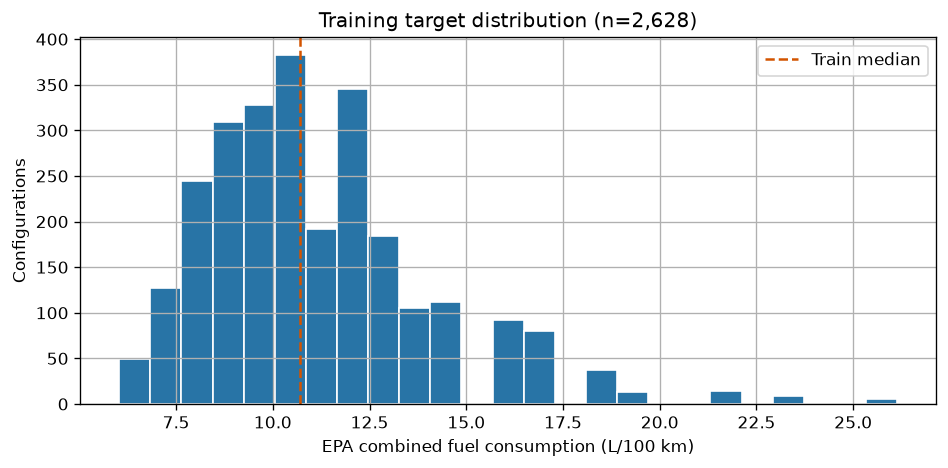

,L/100 km
0.05,7.587567
0.25,9.046715
0.50,10.691572
0.75,12.379715
0.95,16.801042


Train median = **10.69**, mean = **11.15** L/100 km; центральные 90%: 7.59–16.80. Диапазон задает масштаб MAE. Хвост не удаляется только из-за высоких значений: они могут быть допустимыми конфигурациями; validity проверяет cleaner.

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
train[target].hist(bins=25, ax=ax, color='#2874a6', edgecolor='white')
ax.axvline(train[target].median(), color='#d35400', linestyle='--', label='Train median')
ax.set(xlabel='EPA combined fuel consumption (L/100 km)', ylabel='Configurations',
       title=f'Training target distribution (n={len(train):,})')
ax.legend(); plt.tight_layout(); plt.show()
quantiles = train[target].quantile([.05, .25, .5, .75, .95])
display(quantiles.rename('L/100 km').to_frame())
display(Markdown(f"Train median = **{train[target].median():.2f}**, mean = **{train[target].mean():.2f}** L/100 km; "
                 f"центральные 90%: {quantiles.loc[.05]:.2f}–{quantiles.loc[.95]:.2f}. "
                 'Диапазон задает масштаб MAE. Хвост не удаляется только из-за высоких значений: '
                 'они могут быть допустимыми конфигурациями; validity проверяет cleaner.'))

## EDA: объем двигателя и расход

Scatter показывает форму связи и различия классов. Корреляция означает ассоциацию,
а не причинный эффект изменения двигателя. Масса и мощность могут быть объяснительной
гипотезой, но в нашем feature set они не измеряются.

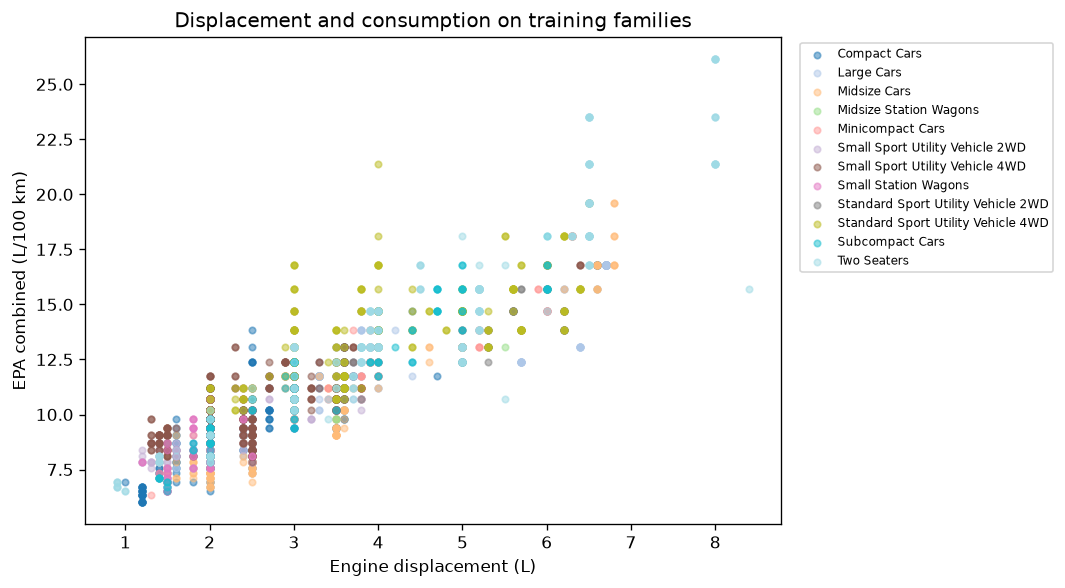

Pearson r = **0.882** на 2,628 train rows с обоими значениями. По r нельзя подтвердить линейность или причинность. Сравниваем Linear Regression с KNN и Decision Tree на одинаковых grouped CV folds.

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
class_groups = list(train.groupby('vehicle_class', sort=True))
class_palette = plt.get_cmap('tab20', len(class_groups))
for index, (label, group) in enumerate(class_groups):
    ax.scatter(group.displacement_l, group[target], label=label, color=class_palette(index), alpha=.5, s=15)
ax.set(xlabel='Engine displacement (L)', ylabel='EPA combined (L/100 km)',
       title='Displacement and consumption on training families')
ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()
association = train[['displacement_l', target]].dropna()
correlation = association.corr().iloc[0, 1]
display(Markdown(f"Pearson r = **{correlation:.3f}** на {len(association):,} train rows с обоими значениями. "
                 'По r нельзя подтвердить линейность или причинность. '
                 'Сравниваем Linear Regression с KNN и Decision Tree на одинаковых grouped CV folds.'))

## EDA: расход и поддержка классов

Совмещаем распределения target и число конфигураций: группа с широкой вариацией или
малым n может иметь нестабильную оценку ошибки. Test ошибки анализируем после выбора модели.

,count,median,mean,std
vehicle_class,,,,
Small Sport Utility Vehicle 4WD,445,10.226721,10.284136,1.398117
Midsize Cars,379,9.046715,9.947173,2.409992
Compact Cars,323,9.046715,9.583944,2.472519
Two Seaters,265,13.067477,14.280947,4.161875
Standard Sport Utility Vehicle 4WD,260,13.836152,13.676889,2.027716
Large Cars,255,11.760729,11.772676,2.413815
Small Sport Utility Vehicle 2WD,229,9.408583,9.466640,1.035856
Subcompact Cars,150,10.946133,11.443532,2.677849
Minicompact Cars,121,12.379715,12.382377,2.109440


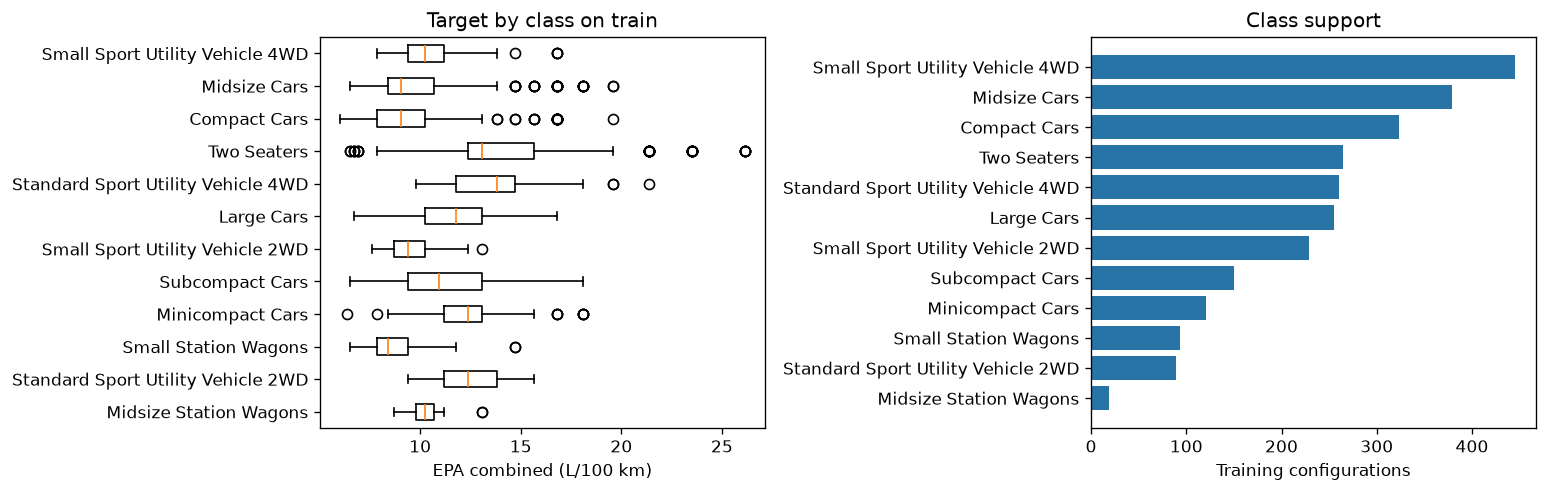

Самый представленный train class — **Small Sport Utility Vehicle 4WD** (445 строк, median 10.23 L/100 km). У 1 классов n<30. Различия классов поддерживают vehicle_class predictor и subgroup MAE analysis; они не доказывают равного качества для всех классов.

In [7]:
class_summary = train.groupby('vehicle_class')[target].agg(['count', 'median', 'mean', 'std']).sort_values('count', ascending=False)
display(class_summary)
order = class_summary.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, .35 * len(order))))
axes[0].boxplot([train.loc[train.vehicle_class.eq(label), target].to_numpy() for label in order],
                orientation='horizontal', tick_labels=order, showfliers=True)
axes[0].set(xlabel='EPA combined (L/100 km)', title='Target by class on train')
axes[1].barh(order, class_summary['count'].to_numpy(), color='#2874a6')
axes[1].invert_yaxis(); axes[0].invert_yaxis()
axes[1].set(xlabel='Training configurations', title='Class support')
plt.tight_layout(); plt.show()
largest = class_summary.iloc[0]
few_classes = class_summary.loc[class_summary['count'].lt(small_threshold)].index.tolist()
display(Markdown(f"Самый представленный train class — **{class_summary.index[0]}** "
                 f"({int(largest['count']):,} строк, median {largest['median']:.2f} L/100 km). "
                 f"У {len(few_classes)} классов n<{small_threshold}. "
                 'Различия классов поддерживают vehicle_class predictor и subgroup MAE analysis; '
                 'они не доказывают равного качества для всех классов.'))

## Модели и train CV

Dummy median — ориентир без спецификаций. Linear Regression — объяснимый аддитивный
ориентир из Week 3. KNN проверяет сходство конфигураций: k=15 снижает чувствительность
к отдельному соседу, distance weights учитывают близость. Decision Tree моделирует
нелинейные пороги/взаимодействия: depth=8, min leaf=10 ограничивают сложность.
KNN и регрессионное дерево подтверждены Lecture 4.

Imputers, numeric scaler и one-hot encoder находятся в sklearn pipeline и fit только
на training portion fold; unknown categories допустимы. Четыре модели получают одинаковые
семь признаков. Параметры заданы до оценки; tuning — следующий этап.

Победитель — минимальный mean train CV MAE. `cv_selection.json` сохраняется **до** test
prediction; test metrics показываются для всех моделей и не меняют победителя.
Mean/std считаются по пяти fold MAE (`ddof=0`). Fold std не confidence interval;
pooled OOF MAE может отличаться от mean fold MAE при разных fold sizes.

In [8]:
display(pd.DataFrame([{'model': name, 'class': item['class'], 'parameters': json.dumps(item['params'], sort_keys=True)}
                      for name, item in config['midterm_models'].items()]))
if EXISTING_RUN is None:
    (ROOT / 'work').mkdir(exist_ok=True)
    temporary_run = tempfile.TemporaryDirectory(prefix='notebook_', dir=ROOT / 'work')
    RUN_ROOT = Path(temporary_run.name)
    run_info = run_midterm(DATASET, CONFIG, 'notebook_run', split_dir=SPLIT_DIR,
                           output_root=RUN_ROOT, allow_small=ALLOW_SMALL)
    RUN_DIR = RUN_ROOT / 'models' / 'notebook_run'
else:
    RUN_DIR = ROOT / EXISTING_RUN
    RUN_ROOT = RUN_DIR.resolve().parent.parent
    run_info = json.loads((RUN_DIR / 'run_metadata.json').read_text(encoding='utf-8'))
    if run_info['status'] != 'completed':
        raise ValueError('Existing run is not completed')
    if run_info['dataset_sha256'] != sha256_file(DATASET):
        raise ValueError('Existing run относится к другому dataset')
    if run_info['split_sha256'] != sha256_file(SPLIT_DIR / 'split_manifest.csv'):
        raise ValueError('Existing run относится к другому split')
    if run_info['config_sha256'] != sha256_file(CONFIG):
        raise ValueError('Existing run относится к другому config')
    if run_info['development_small_dataset'] and not ALLOW_SMALL:
        raise ValueError('Small development run нельзя выдать за достаточный benchmark')
    print('Сохраненные результаты; повторное обучение не выполняется.')
selection = json.loads((RUN_DIR / 'cv_selection.json').read_text(encoding='utf-8'))
assert selection['selection_source'] == 'train_group_cv'
assert run_info['test_used_for_selection'] is False
TABLES = RUN_ROOT / Path(run_info['reports_path'].replace('\\', '/'))
if sha256_file(TABLES / 'predictions.csv') != run_info['predictions_sha256']:
    raise ValueError('Saved predictions checksum changed')
metrics = pd.read_csv(TABLES / 'metrics.csv')
assert set(metrics.model) == {'dummy', 'linear', 'knn', 'tree'} and len(metrics) == 4
display(metrics[['model', 'n_train', 'n_test', 'n_folds', 'cv_mae_mean', 'cv_mae_std',
                 'test_mae', 'test_rmse', 'test_r2', 'cv_improvement_over_dummy_pct',
                 'test_improvement_over_dummy_pct', 'selected_by_cv']].round(4))
display(pd.read_csv(TABLES / 'fold_metrics.csv'))
selected_model = run_info['selected_model']
selected_metrics = metrics.loc[metrics.model.eq(selected_model)].iloc[0]
display(Markdown(f"**По train CV выбрана {selected_model}:** MAE "
                 f"{selected_metrics.cv_mae_mean:.3f} ± {selected_metrics.cv_mae_std:.3f} L/100 km. "
                 f"CV improvement относительно dummy: {selected_metrics.cv_improvement_over_dummy_pct:.1f}%. "
                 f"Test MAE = {selected_metrics.test_mae:.3f} L/100 km, "
                 f"RMSE = {selected_metrics.test_rmse:.3f}, R² = {selected_metrics.test_r2:.3f}. "
                 'R² не процент правильно предсказанных автомобилей.'))

,model,class,parameters
0,dummy,DummyRegressor,"{""strategy"": ""median""}"
1,linear,LinearRegression,"{""fit_intercept"": true}"
2,knn,KNeighborsRegressor,"{""n_neighbors"": 15, ""p"": 2, ""weights"": ""distan..."
3,tree,DecisionTreeRegressor,"{""criterion"": ""squared_error"", ""max_depth"": 8,..."


Сохраненные результаты; повторное обучение не выполняется.


,model,n_train,n_test,n_folds,cv_mae_mean,cv_mae_std,test_mae,test_rmse,test_r2,cv_improvement_over_dummy_pct,test_improvement_over_dummy_pct,selected_by_cv
0,dummy,2628,619,5,2.2088,0.3047,2.5970,3.1373,-0.0173,0.0000,0.0000,False
1,linear,2628,619,5,0.8134,0.1200,0.7138,0.8996,0.9164,63.1736,72.5156,True
2,knn,2628,619,5,0.9143,0.0697,0.6924,0.9071,0.9150,58.6064,73.3364,False
3,tree,2628,619,5,0.8924,0.0614,0.9167,1.4127,0.7937,59.5961,64.7024,False


,run_id,model,fold,n_train,n_valid,mae,rmse,r2,fit_seconds
0,midterm_v1,dummy,0,2102,526,2.174981,2.979715,-0.297067,0.102970
1,midterm_v1,dummy,1,2102,526,2.783960,4.016891,-0.064569,0.038973
2,midterm_v1,dummy,2,2102,526,1.878762,2.292871,-0.007026,0.038849
3,midterm_v1,dummy,3,2103,525,2.125201,2.711859,-0.094551,0.037526
4,midterm_v1,dummy,4,2103,525,2.080894,2.550485,-0.009824,0.041633
5,midterm_v1,linear,0,2102,526,0.995611,1.296484,0.754446,0.077624
6,midterm_v1,linear,1,2102,526,0.790129,1.247572,0.897311,0.062812
7,midterm_v1,linear,2,2102,526,0.678073,0.882368,0.850864,0.060540
8,midterm_v1,linear,3,2103,525,0.900727,1.241847,0.770471,0.062617
9,midterm_v1,linear,4,2103,525,0.702493,0.887363,0.877763,0.065040


**По train CV выбрана linear:** MAE 0.813 ± 0.120 L/100 km. CV improvement относительно dummy: 63.2%. Test MAE = 0.714 L/100 km, RMSE = 0.900, R² = 0.916. R² не процент правильно предсказанных автомобилей.

## Ошибки: train OOF и test

Residual = prediction − actual: положительный означает завышение расхода.
Train OOF прогноз каждой строки получен моделью, не обученной на ее семействе.
OOF обосновывает следующие эксперименты; test диагностирует выбранную модель,
но не служит подбору новых параметров.

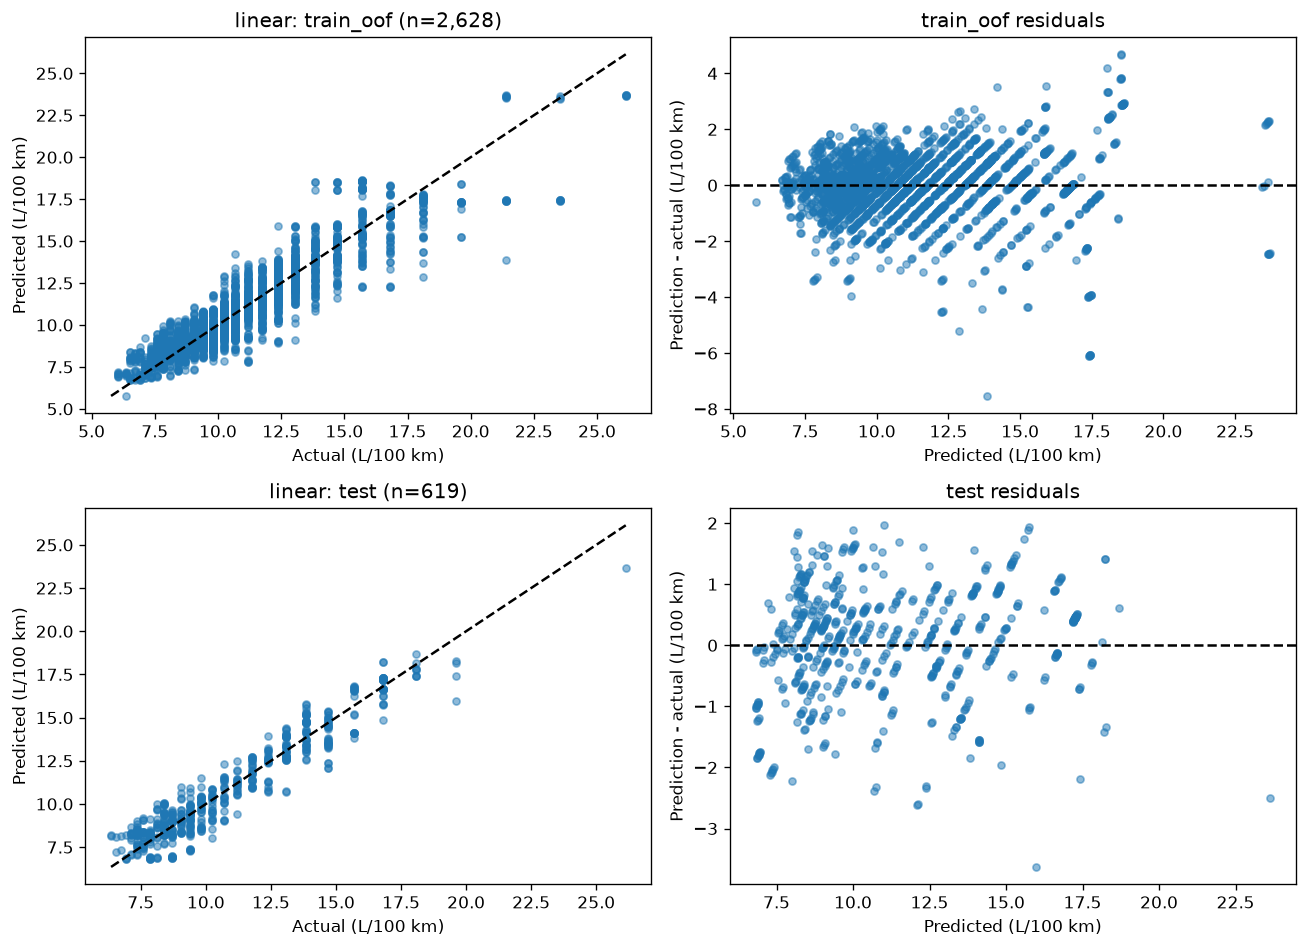

,n,pooled_mae,median_absolute_error,bias
split,,,,
test,619,0.713764,0.589092,0.043709
train_oof,2628,0.813415,0.622617,0.041474


Mean residual: train OOF 0.041, test 0.044 L/100 km. Bias около нуля может скрывать противоположные ошибки разных групп.

In [9]:
predictions = pd.read_csv(TABLES / 'predictions.csv', dtype={'vehicle_id': str})
best = predictions.loc[predictions.model.eq(selected_model)].copy()
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, split_name in enumerate(['train_oof', 'test']):
    group = best.loc[best['split'].eq(split_name)]
    axes[row, 0].scatter(group.y_true, group.y_pred, alpha=.5, s=18)
    bounds = [min(group.y_true.min(), group.y_pred.min()), max(group.y_true.max(), group.y_pred.max())]
    axes[row, 0].plot(bounds, bounds, 'k--')
    axes[row, 0].set(xlabel='Actual (L/100 km)', ylabel='Predicted (L/100 km)',
                     title=f'{selected_model}: {split_name} (n={len(group):,})')
    axes[row, 1].scatter(group.y_pred, group.residual, alpha=.5, s=18)
    axes[row, 1].axhline(0, color='black', linestyle='--')
    axes[row, 1].set(xlabel='Predicted (L/100 km)', ylabel='Prediction - actual (L/100 km)',
                     title=f'{split_name} residuals')
plt.tight_layout(); plt.show()
error_summary = best.groupby('split').agg(n=('vehicle_id', 'size'), pooled_mae=('abs_error', 'mean'),
                                          median_absolute_error=('abs_error', 'median'), bias=('residual', 'mean'))
display(error_summary)
display(Markdown(f"Mean residual: train OOF {error_summary.loc['train_oof', 'bias']:.3f}, "
                 f"test {error_summary.loc['test', 'bias']:.3f} L/100 km. "
                 'Bias около нуля может скрывать противоположные ошибки разных групп.'))

## Ошибки по vehicle class и engine size

Заранее определенные интервалы: (0,2], (2,3], (3,4], (4,+∞) L; missing отдельно.
Для всех моделей и обоих splits показываем n, MAE, median absolute error и bias.
При n<30 поддержка мала; описательное сравнение не доказывает надежность группы.

In [10]:
subgroup = pd.read_csv(TABLES / 'subgroup_errors.csv')
for field in ['vehicle_class', 'engine_size_bin']:
    display(Markdown(f'**{field}: all models, OOF + test**'))
    display(subgroup.loc[subgroup.subgroup_field.eq(field),
                         ['model', 'split', 'subgroup', 'n', 'mae', 'median_absolute_error', 'bias', 'small_support']]
            .sort_values(['split', 'model', 'subgroup']).reset_index(drop=True))
selected_groups = subgroup.loc[subgroup.model.eq(selected_model)]
for split_name in ['train_oof', 'test']:
    supported = selected_groups.loc[selected_groups['split'].eq(split_name)
                                     & selected_groups.n.ge(small_threshold)].sort_values('mae', ascending=False)
    if supported.empty:
        display(Markdown(f'**{split_name}:** нет estimates с n≥{small_threshold}; '
                         'не ранжируем надежность групп как установленный факт.'))
    else:
        worst = supported.iloc[0]
        display(Markdown(f"**{split_name}, поддержанные группы:** наибольший наблюдаемый MAE "
                         f"у {worst.subgroup_field} = {worst.subgroup}: {worst.mae:.3f} L/100 km "
                         f"(n={int(worst.n)}). Это оценка текущего split, не причинный вывод."))
large_errors = pd.read_csv(TABLES / 'large_errors.csv', dtype={'vehicle_id': str})
display(Markdown('**Реальные test-конфигурации с наибольшей ошибкой выбранной по CV модели.**'))
display(large_errors.loc[large_errors.model.eq(selected_model)].head(10))
oof_examples = best.loc[best['split'].eq('train_oof')].nlargest(10, 'abs_error')
oof_examples = oof_examples.merge(df[['vehicle_id'] + feature_cols + ['model_name']], on='vehicle_id', validate='one_to_one')
display(Markdown('**Train OOF примеры для планирования следующих экспериментов.**'))
display(oof_examples)

**vehicle_class: all models, OOF + test**

,model,split,subgroup,n,mae,median_absolute_error,bias,small_support
0,dummy,test,Compact Cars,67,2.057715,2.291051e+00,1.853560,False
1,dummy,test,Large Cars,53,4.083036,4.989400e+00,-2.185558,False
2,dummy,test,Midsize Cars,95,2.799780,3.104005e+00,-1.458093,False
3,dummy,test,Midsize Station Wagons,11,5.596323,6.109470e+00,-5.511804,True
4,dummy,test,Minicompact Cars,69,2.228418,2.291051e+00,1.408957,False
5,dummy,test,Small Sport Utility Vehicle 2WD,38,1.848298,1.644857e+00,1.765230,False
6,dummy,test,Small Sport Utility Vehicle 4WD,51,1.276163,8.909643e-01,0.977345,False
7,dummy,test,Small Station Wagons,15,1.933994,1.979921e+00,1.933994,True
8,dummy,test,Standard Sport Utility Vehicle 2WD,22,2.573351,2.760242e+00,-2.531092,True
9,dummy,test,Standard Sport Utility Vehicle 4WD,34,3.284338,3.144580e+00,-3.284338,False


**engine_size_bin: all models, OOF + test**

,model,split,subgroup,n,mae,median_absolute_error,bias,small_support
0,dummy,test,"(0,2] L",285,2.187080,2.291051,2.118194,False
1,dummy,test,"(2,3] L",63,1.198495,1.069157,0.695030,False
2,dummy,test,"(3,4] L",108,1.644058,1.378650,-1.568017,False
3,dummy,test,"(4,+inf) L",163,4.485582,4.009339,-4.485582,False
4,knn,test,"(0,2] L",285,0.699684,0.570701,0.363417,False
5,knn,test,"(2,3] L",63,0.691737,0.560035,0.296502,False
6,knn,test,"(3,4] L",108,0.798208,0.648757,-0.243696,False
7,knn,test,"(4,+inf) L",163,0.610002,0.474555,0.133518,False
8,linear,test,"(0,2] L",285,0.747122,0.652725,0.014181,False
9,linear,test,"(2,3] L",63,0.697786,0.584960,0.159865,False


**train_oof, поддержанные группы:** наибольший наблюдаемый MAE у vehicle_class = Two Seaters: 1.421 L/100 km (n=265). Это оценка текущего split, не причинный вывод.

**test, поддержанные группы:** наибольший наблюдаемый MAE у vehicle_class = Standard Sport Utility Vehicle 4WD: 1.030 L/100 km (n=34). Это оценка текущего split, не причинный вывод.

**Реальные test-конфигурации с наибольшей ошибкой выбранной по CV модели.**

,vehicle_id,model,split,model_year,manufacturer,model_name,displacement_l,cylinders,transmission,drivetrain,vehicle_class,engine_size_bin,y_true,y_pred,residual,abs_error
20,38135,linear,test,2017,Aston Martin,V12 Vantage S,6.0,12,Manual 7-spd,Rear-Wheel Drive,Two Seaters,"(4,+inf) L",19.601215,15.973402,-3.627814,3.627814
21,35481,linear,test,2015,Land Rover,LR4,3.0,6,Automatic (S8),4-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(2,3] L",14.700911,12.086761,-2.614150,2.614150
22,36379,linear,test,2016,Land Rover,LR4,3.0,6,Automatic (S8),4-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(2,3] L",14.700911,12.110363,-2.590548,2.590548
23,48578,linear,test,2025,Bugatti,Mistral,8.0,16,Automatic (AM-S7),All-Wheel Drive,Two Seaters,"(4,+inf) L",26.134954,23.634524,-2.500430,2.500430
24,42652,linear,test,2020,Land Rover,Defender 110,2.0,4,Automatic (S8),4-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(0,2] L",13.067477,10.679102,-2.388375,2.388375
25,47759,linear,test,2024,Porsche,718 Spyder RS,4.0,6,Automatic (AM-S7),Rear-Wheel Drive,Two Seaters,"(3,4] L",14.700911,12.370182,-2.330730,2.330730
26,45105,linear,test,2023,Land Rover,Defender 110,2.0,4,Automatic (S8),4-Wheel Drive,Standard Sport Utility Vehicle 4WD,"(0,2] L",13.067477,10.749909,-2.317568,2.317568
27,48816,linear,test,2025,Porsche,718 GT4 RS,4.0,6,Automatic (AM-S7),Rear-Wheel Drive,Two Seaters,"(3,4] L",14.700911,12.393784,-2.307127,2.307127
28,37192,linear,test,2016,Buick,Cascada,1.6,4,Automatic (S6),Front-Wheel Drive,Subcompact Cars,"(0,2] L",10.226721,8.012522,-2.214199,2.214199
29,37605,linear,test,2017,Ferrari,F12 tdf,6.3,12,Automatic (AM7),Rear-Wheel Drive,Two Seaters,"(4,+inf) L",19.601215,17.405621,-2.195594,2.195594


**Train OOF примеры для планирования следующих экспериментов.**

,vehicle_id,split,fold,y_true,y_pred,residual,abs_error,model,model_year,displacement_l,cylinders,manufacturer,transmission,drivetrain,vehicle_class,model_name
0,47689,train_oof,0.0,21.383144,13.851493,-7.531651,7.531651,linear,2024,4.0,8,Mercedes-Benz,Automatic 9-spd,4-Wheel Drive,Standard Sport Utility Vehicle 4WD,AMG G63 4x4 Squared
1,43409,train_oof,1.0,23.521458,17.406967,-6.114491,6.114491,linear,2020,6.5,12,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Aventador Sian Roadster
2,43410,train_oof,1.0,23.521458,17.406967,-6.114491,6.114491,linear,2020,6.5,12,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Aventador Sian Coupe
3,43485,train_oof,1.0,23.521458,17.438303,-6.083156,6.083156,linear,2021,6.5,12,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Aventador Coupe
4,43486,train_oof,1.0,23.521458,17.438303,-6.083156,6.083156,linear,2021,6.5,12,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Aventador Roadster
5,43757,train_oof,1.0,23.521458,17.438303,-6.083156,6.083156,linear,2021,6.5,12,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Aventador Sian Coupe
6,43758,train_oof,1.0,23.521458,17.438303,-6.083156,6.083156,linear,2021,6.5,12,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Aventador Sian Roadster
7,38458,train_oof,0.0,18.093429,12.872426,-5.221003,5.221003,linear,2017,4.0,8,Mercedes-Benz,Automatic 7-spd,4-Wheel Drive,Standard Sport Utility Vehicle 4WD,G550
8,37471,train_oof,3.0,13.836152,18.518384,4.682232,4.682232,linear,2017,5.2,10,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Huracan
9,36933,train_oof,3.0,13.836152,18.504389,4.668237,4.668237,linear,2016,5.2,10,Lamborghini,Automatic (AM-S7),All-Wheel Drive,Two Seaters,Huracan


## Ответ, ограничения и следующий этап

Сводка вычисляется из результатов; она не подменяет интерпретацию графиков командой.
Smoke scores не называются оценкой полного рынка. Вклад участников должен быть подтвержден contribution log.

In [11]:
sample_label = 'ограниченного технического snapshot' if run_info['development_small_dataset'] else 'этого frozen benchmark'
display(Markdown(f"Для **{sample_label}** семь спецификаций и модель {selected_model}, выбранная по train CV, "
                 f"дают test MAE **{selected_metrics.test_mae:.3f} L/100 km** на "
                 f"{split_info['n_test_groups']} удержанных семействах ({split_info['n_test']:,} конфигураций). "
                 f"Изменение test MAE относительно dummy в сторону улучшения: "
                 f"{selected_metrics.test_improvement_over_dummy_pct:.1f}% (отрицательное означает ухудшение). "
                 'Это средняя ошибка EPA target, не гарантированный интервал каждой машины '
                 'и не точность реального дорожного расхода.'))
limitations = [
    f'Покрытие: {df.manufacturer.nunique()} производителей, {df.vehicle_class.nunique()} классов, '
    f'годы {int(df.model_year.min())}–{int(df.model_year.max())}; конфигурации не взвешены по продажам.',
    'Target из rounded comb08; преобразование L/100 km нелинейно. Результаты ограничены EPA методикой/округлением.',
    'Группы из source baseModel и audit aliases; общие платформы между разными именами могут оставаться связанными.',
    'Масса, мощность, аэродинамика и поведение водителя не predictors; объяснения ошибок через них — гипотезы.',
    f'Группы с n<{small_threshold} имеют малую поддержку. Fold std не confidence interval.',
    'После Midterm test раскрыт; tuning остается на train grouped CV, сравнение этапов — на тех же test IDs.'
]
if run_info['development_small_dataset']:
    limitations.insert(0, 'Меньше 1 000 retained rows: технический прогон не выполняет minimum benchmark requirement.')
if cleaning_summary:
    limitations.append(f"Category status: {cleaning_summary.get('category_allowlist_status')}; "
                       f"unresolved duplicate candidates: {cleaning_summary.get('unresolved_candidate_groups')}. "
                       'Минимум строк не подтверждает complete catalogue traversal; проверяем collection manifest.')
display(Markdown('\n'.join('- ' + text for text in limitations)))
display(pd.DataFrame([
    {'basis / hypothesis': f'OOF MAE {error_summary.loc["train_oof", "pooled_mae"]:.3f}; possible nonlinear interactions',
     'next experiment': 'Tuned ensembles with nested train GroupKFold',
     'evidence': 'OOF/CV vs best Midterm; fixed test for final comparison'},
    {'basis / hypothesis': f'{len(train):,} train rows; class composition differs',
     'next experiment': 'Clustering and PCA, fit without target',
     'evidence': 'Stable segments/structure; no automatic MAE improvement claim'},
    {'basis / hypothesis': 'Nonlinear capacity: untested next-stage hypothesis',
     'next experiment': 'MLP with explicit grouped validation',
     'evidence': 'Train CV and fixed test; prevent group leakage in early stopping'},
    {'basis / hypothesis': f'Engine text missing fraction {retained_missing.loc["engine_description", "missing_fraction"]:.1%}',
     'next experiment': 'Final structured vs model/engine text, fold-fit TF-IDF',
     'evidence': 'Same IDs; sanitize leakage text; paired absolute-error differences'}
]))
display(Markdown('Вклад и AI: `docs/CONTRIBUTIONS.md`; source/scope: `docs/DATA_CARD.md`; '
                 'course requirements и неизвестные dates/approval: `docs/REQUIREMENTS.md`. '
                 'Слайды и участие обоих студентов на защите — отдельные артефакты.'))

Для **этого frozen benchmark** семь спецификаций и модель linear, выбранная по train CV, дают test MAE **0.714 L/100 km** на 78 удержанных семействах (619 конфигураций). Изменение test MAE относительно dummy в сторону улучшения: 72.5% (отрицательное означает ухудшение). Это средняя ошибка EPA target, не гарантированный интервал каждой машины и не точность реального дорожного расхода.

- Покрытие: 49 производителей, 12 классов, годы 2015–2025; конфигурации не взвешены по продажам.
- Target из rounded comb08; преобразование L/100 km нелинейно. Результаты ограничены EPA методикой/округлением.
- Группы из source baseModel и audit aliases; общие платформы между разными именами могут оставаться связанными.
- Масса, мощность, аэродинамика и поведение водителя не predictors; объяснения ошибок через них — гипотезы.
- Группы с n<30 имеют малую поддержку. Fold std не confidence interval.
- После Midterm test раскрыт; tuning остается на train grouped CV, сравнение этапов — на тех же test IDs.
- Category status: verify_against_full_inventory_before_freeze; unresolved duplicate candidates: 0. Минимум строк не подтверждает complete catalogue traversal; проверяем collection manifest.

,basis / hypothesis,next experiment,evidence
0,OOF MAE 0.813; possible nonlinear interactions,Tuned ensembles with nested train GroupKFold,OOF/CV vs best Midterm; fixed test for final c...
1,"2,628 train rows; class composition differs","Clustering and PCA, fit without target",Stable segments/structure; no automatic MAE im...
2,Nonlinear capacity: untested next-stage hypoth...,MLP with explicit grouped validation,Train CV and fixed test; prevent group leakage...
3,Engine text missing fraction 23.9%,"Final structured vs model/engine text, fold-fi...",Same IDs; sanitize leakage text; paired absolu...


Вклад и AI: `docs/CONTRIBUTIONS.md`; source/scope: `docs/DATA_CARD.md`; course requirements и неизвестные dates/approval: `docs/REQUIREMENTS.md`. Слайды и участие обоих студентов на защите — отдельные артефакты.

## Воспроизводимость

Collection не запускается внутри notebook. Dataset/split проходят checksum validation;
обучение сохраняет параметры, версии, CV selection до test, per-row predictions и model checksums.
Temporary refit не перезаписывает основной run.

In [12]:
print({'dataset_sha256': run_info['dataset_sha256'], 'split_sha256': run_info['split_sha256'],
       'config_sha256': run_info['config_sha256'], 'selected_by': run_info['selection_source'],
       'test_used_for_selection': run_info['test_used_for_selection'],
       'python': run_info['python_version'], 'packages': run_info['package_versions'],
       'development_small_dataset': run_info['development_small_dataset']})
print('Stored tables:', TABLES)

{'dataset_sha256': 'f9152b6d24577b2abeb5c149fd5a247a49d9c098c7d0dd50202ed8d1ad652739', 'split_sha256': '8ad5db3c3f606ef862fdbf8c72c215da93a8ec786ac208351370f8180352b9df', 'config_sha256': '3101b33715afa7d1ffe7ddb3d224a266ef35a98ee40a0c3dc918f8bfcd336df8', 'selected_by': 'train_group_cv', 'test_used_for_selection': False, 'python': '3.12.14', 'packages': {'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'joblib': '1.6.0'}, 'development_small_dataset': False}
Stored tables: C:\Users\Nikeka\Documents\Codex\2026-10-09\group-se-2421-team-members-tsybus\outputs\fuel_consumption_project\reports\tables\midterm_v1
